In [1]:
# [Cell 1: Environment Configuration and Library Imports]
# Install required packages (uncomment if running in a clean environment)
!pip install qiskit qiskit-aer qiskit-algorithms numpy scipy matplotlib

import numpy as np
import matplotlib.pyplot as plt
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit_aer.primitives import Estimator as AerEstimator
from qiskit_aer import AerSimulator
from scipy.optimize import minimize

# Configure Matplotlib for academic-standard objective plotting
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.grid': True,
    'grid.linestyle': ':',
    'grid.alpha': 0.6,
    'figure.figsize': (10, 6)
})

print("Environment setup complete. Qiskit primitives and numerical libraries imported.")

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3.13 -m pip install --upgrade pip
Environment setup complete. Qiskit primitives and numerical libraries imported.


VQE Minimum Energy: -3.000000 (Exact: -3.000000)
Subspace Fidelity : F = 1.000000

--- Optimized Theta Parameters ---
Raw Array:
[-8.62711758e-05  3.14262042e+00 -7.17986254e-01  1.57146882e+00
 -2.55910863e+00 -1.57001532e+00 -3.85967203e+00  4.71313560e+00
  9.88303696e-01  3.14098710e+00 -4.71244683e+00  6.28316058e+00
  1.73671956e+00 -1.50321271e+00 -1.80629212e+00 -1.71121451e+00]

Formatted Array (radians):
theta[0] = -0.000086
theta[1] = +3.142620
theta[2] = -0.717986
theta[3] = +1.571469
theta[4] = -2.559109
theta[5] = -1.570015
theta[6] = -3.859672
theta[7] = +4.713136
theta[8] = +0.988304
theta[9] = +3.140987
theta[10] = -4.712447
theta[11] = +6.283161
theta[12] = +1.736720
theta[13] = -1.503213
theta[14] = -1.806292
theta[15] = -1.711215
----------------------------------------


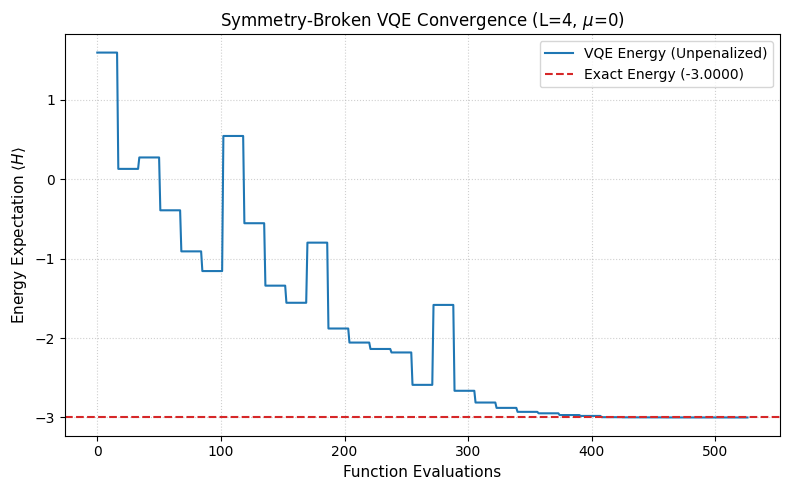

In [11]:
# [Cell 2: Symmetry-Broken VQE for Pure Parity Ground State Selection]
import time
import numpy as np
import matplotlib.pyplot as plt

from qiskit.circuit.library import efficient_su2
from qiskit.quantum_info import Statevector, SparsePauliOp

from qiskit_aer.primitives import Estimator as AerEstimator
from scipy.optimize import minimize

def build_real_ansatz(L: int, reps: int = 3):
    return efficient_su2(L, su2_gates=['ry'], entanglement='linear', reps=reps)

target_L = 4
target_depth = 3


pauli_list = []
for j in range(target_L - 1):
    op_str = ['I'] * target_L
    op_str[j] = 'Y'
    op_str[j+1] = 'Y'
   
    pauli_list.append(("".join(op_str)[::-1], 1.0))

H_op = SparsePauliOp.from_list(pauli_list)
# ==========================================

ansatz = build_real_ansatz(target_L, target_depth)
estimator = AerEstimator(approximation=True) 

H_mat = H_op.to_matrix()
eigenvalues, eigenvectors = np.linalg.eigh(H_mat)

exact_gs_energy = eigenvalues[0]
degenerate_indices = np.where(eigenvalues < exact_gs_energy + 1e-6)[0]

# Construct Global Parity Operator: P = Z_0 Z_1 ... Z_{L-1}
parity_string = 'Z' * target_L
parity_op = SparsePauliOp.from_list([(parity_string, 1.0)])

energy_history = []
def cost_function(params):
    # Evaluate Physical Energy
    job_h = estimator.run(ansatz, H_op, parameter_values=[params])
    energy = job_h.result().values[0]
    
    # Evaluate System Parity
    job_p = estimator.run(ansatz, parity_op, parameter_values=[params])
    parity_val = job_p.result().values[0]
    
    # Apply Symmetry-Breaking Penalty (lambda = 0.1)
    # Minimizing this cost function strictly forces parity_val -> +1 (Even Parity Sector)
    lambda_penalty = 0.1
    total_cost = energy - lambda_penalty * parity_val
    
    energy_history.append(energy)
    return total_cost

np.random.seed(42)
initial_params = np.random.uniform(-np.pi, np.pi, ansatz.num_parameters)

start_time = time.time()
opt_result = minimize(
    cost_function,
    initial_params,
    method='L-BFGS-B', 
    options={'maxiter': 10000, 'ftol': 1e-6}
)

optimized_qc = ansatz.assign_parameters(opt_result.x)
psi_vqe = Statevector(optimized_qc).data

subspace_fidelity = 0.0
for idx in degenerate_indices:
    subspace_fidelity += np.abs(np.vdot(eigenvectors[:, idx], psi_vqe))**2

print(f"VQE Minimum Energy: {energy_history[-1]:.6f} (Exact: {exact_gs_energy:.6f})")
print(f"Subspace Fidelity : F = {subspace_fidelity:.6f}")


print("\n--- Optimized Theta Parameters ---")
print("Raw Array:")
print(opt_result.x)

print("\nFormatted Array (radians):")
for i, theta_val in enumerate(opt_result.x):
    print(f"theta[{i}] = {theta_val:+.6f}")
print("----------------------------------------")

if subspace_fidelity < 0.99:
    raise RuntimeError(f"PROGRESS HALTED: Fidelity {subspace_fidelity:.4f} is below 0.99.")

plt.figure(figsize=(8, 5))
plt.plot(energy_history, color='#1f77b4', linewidth=1.5, label='VQE Energy (Unpenalized)')
plt.axhline(y=exact_gs_energy, color='#d62728', linestyle='--', label=f'Exact Energy ({exact_gs_energy:.4f})')
plt.title(rf'Symmetry-Broken VQE Convergence (L={target_L}, $\mu$=0)', fontsize=12)
plt.xlabel('Function Evaluations', fontsize=11)
plt.ylabel(r'Energy Expectation $\langle H \rangle$', fontsize=11)
plt.legend()
plt.tight_layout()  
plt.show()

<>:72: SyntaxWarning: invalid escape sequence '\p'
<>:72: SyntaxWarning: invalid escape sequence '\p'
/var/folders/lv/lyy0kw2s3ljbtwq1mfknqdj80000gn/T/ipykernel_36327/1017897957.py:72: SyntaxWarning: invalid escape sequence '\p'
  f'{yval:.4f} \n $\pm${err_val:.4f}', ha='center', va='bottom', fontsize=10)


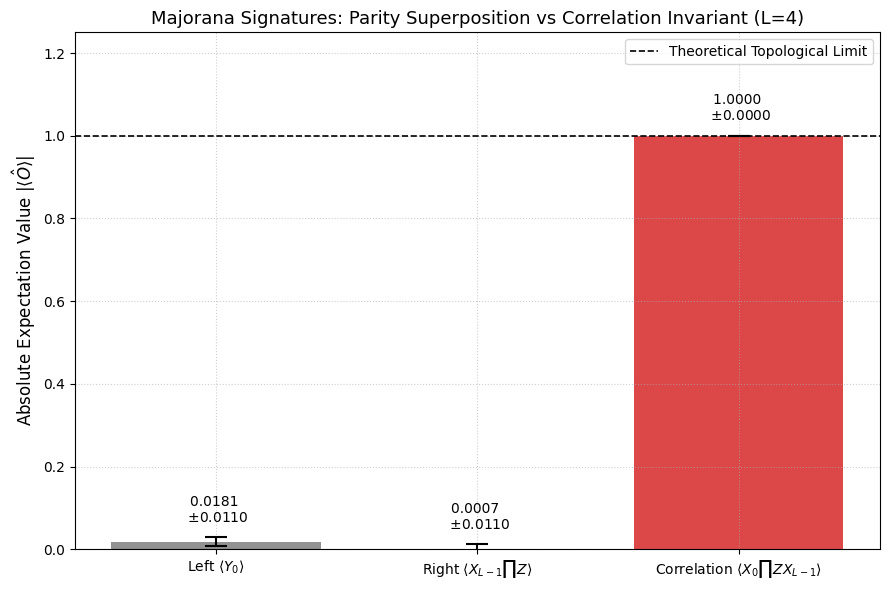

In [ ]:
# [Cell 3: Topologically Valid Quantum Measurements and Signature Visualization]
import numpy as np
import matplotlib.pyplot as plt
from qiskit import transpile
from qiskit_aer import AerSimulator 

def execute_topological_measurements(optimal_circuit, L, shots=8192):
    """
    Executes shot-based sampling to extract the true Majorana signatures for the YY-dominated Hamiltonian.
    1. Single Left Mode: <Y_0>
    2. Single Right Mode: <X_{L-1} Z_{L-2}...Z_0>
    3. Edge-Edge Correlation: <X_0 Z_1...Z_{L-2} X_{L-1}>
    """
    backend = AerSimulator()
    
    # --- Observable 1: Left Edge <Y_0> ---
    meas_l = optimal_circuit.copy()
    meas_l.sdg(0)
    meas_l.h(0)
    meas_l.measure_all()
    job_l = backend.run(transpile(meas_l, backend), shots=shots)
    counts_l = job_l.result().get_counts()
    # Qiskit uses Big-endian (q_{L-1} ... q_0), so q_0 is at index -1
    e_left = sum((-1 if bs[-1] == '1' else 1) * count for bs, count in counts_l.items()) / shots
    
    # --- Observable 2: Right Edge <X_{L-1} Z_{L-2}...Z_0> ---
    meas_r = optimal_circuit.copy()
    meas_r.h(L-1)
    meas_r.measure_all()
    job_r = backend.run(transpile(meas_r, backend), shots=shots)
    counts_r = job_r.result().get_counts()
    e_right = sum((1 if bs.count('1') % 2 == 0 else -1) * count for bs, count in counts_r.items()) / shots

    # --- Observable 3: Edge-Edge Correlation <X_0 Z_1...Z_{L-2} X_{L-1}> ---
    meas_corr = optimal_circuit.copy()
    meas_corr.h(0)     # X basis for qubit 0
    meas_corr.h(L-1)   # X basis for qubit L-1
    meas_corr.measure_all()
    job_corr = backend.run(transpile(meas_corr, backend), shots=shots)
    counts_corr = job_corr.result().get_counts()
    e_corr = sum((1 if bs.count('1') % 2 == 0 else -1) * count for bs, count in counts_corr.items()) / shots
    
    # --- Calculate Standard Error of the Mean (SEM) ---
    se_left = np.sqrt(1 - e_left**2) / np.sqrt(shots)
    se_right = np.sqrt(1 - e_right**2) / np.sqrt(shots)
    se_corr = np.sqrt(1 - e_corr**2) / np.sqrt(shots)
    
    return (e_left, e_right, e_corr), (se_left, se_right, se_corr)

expectations, standard_errors = execute_topological_measurements(optimized_qc, target_L, shots=8192)

e_left, e_right, e_corr = expectations
se_left, se_right, se_corr = standard_errors

# Visualization: Superposition Collapse vs True Invariant
labels = [r'Left $\langle Y_0 \rangle$', r'Right $\langle X_{L-1} \prod Z \rangle$', r'Correlation $\langle X_0 \prod Z X_{L-1} \rangle$']
measured_vals = [np.abs(e_left), np.abs(e_right), np.abs(e_corr)]
errors = [se_left, se_right, se_corr]

plt.figure(figsize=(9, 6))

bars = plt.bar(labels, measured_vals, yerr=errors, capsize=8, 
               color=['#7f7f7f', '#7f7f7f', '#d62728'], alpha=0.85, 
               error_kw=dict(lw=1.5, capthick=1.5, ecolor='black'))


for i, bar in enumerate(bars):
    yval = bar.get_height()
    err_val = errors[i]
    plt.text(bar.get_x() + bar.get_width()/2, yval + err_val + 0.03, 
             f'{yval:.4f} \n $\pm${err_val:.4f}', ha='center', va='bottom', fontsize=10)

plt.axhline(1.0, color='black', linestyle='--', linewidth=1.2, label='Theoretical Topological Limit')
plt.ylim(0, 1.25) 
plt.ylabel(r'Absolute Expectation Value $|\langle \hat{O} \rangle|$', fontsize=12)
plt.title(f'Majorana Signatures: Parity Superposition vs Correlation Invariant (L={target_L})', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

Generating Ansatz Plot...


/var/folders/lv/lyy0kw2s3ljbtwq1mfknqdj80000gn/T/ipykernel_21461/3882569816.py:29: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz_viz = EfficientSU2(L, su2_gates=['ry'], entanglement='linear', reps=1)


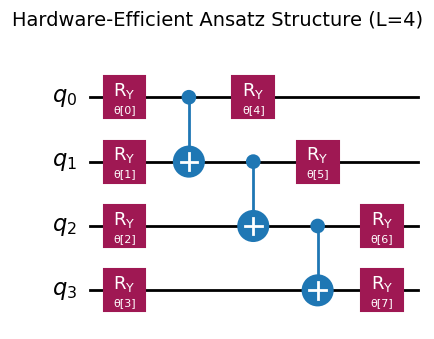

Generating Correlation Measurement Protocol Plot...


/var/folders/lv/lyy0kw2s3ljbtwq1mfknqdj80000gn/T/ipykernel_21461/3882569816.py:44: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  qc_corr.append(EfficientSU2(L, su2_gates=['ry'], reps=1).to_gate(label="VQE GS Ansatz"), range(L))


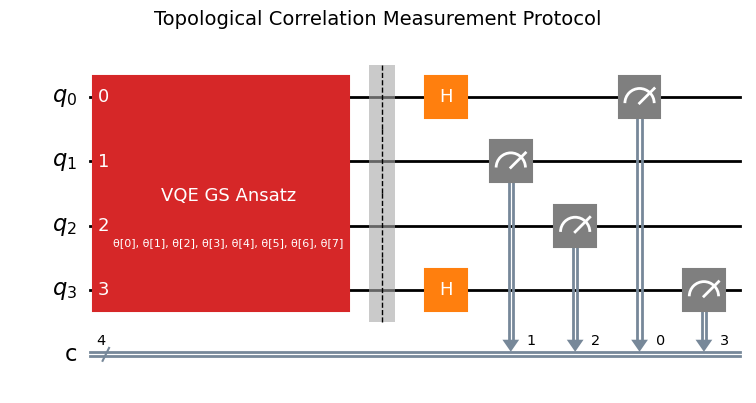

In [ ]:
# [Cell 4: Quantum Circuit Visualization for Presentation]
import matplotlib.pyplot as plt
from IPython.display import display
from qiskit import QuantumCircuit
from qiskit.circuit.library import EfficientSU2


circuit_style = {
    "backgroundcolor": "#ffffff",
    "linecolor": "#000000",
    "gatefacecolor": "#d62728", #
    "gatetextcolor": "#ffffff",
    "displaycolor": {
        "cx": "#1f77b4",       # 
        "h": "#ff7f0e",        # 
        "measure": "#7f7f7f"   
    }
}

def generate_presentation_circuits(L: int):

    ansatz_viz = EfficientSU2(L, su2_gates=['ry'], entanglement='linear', reps=1)
    ansatz_viz = ansatz_viz.decompose() 
    
    print("Generating Ansatz Plot...")
    fig_ansatz = ansatz_viz.draw(output='mpl', style=circuit_style)
    fig_ansatz.axes[0].set_title(f"Hardware-Efficient Ansatz Structure (L={L})", pad=15, fontsize=14)
    display(fig_ansatz)
    plt.close(fig_ansatz)


    qc_corr = QuantumCircuit(L, L)
    
  
    qc_corr.append(EfficientSU2(L, su2_gates=['ry'], reps=1).to_gate(label="VQE GS Ansatz"), range(L))
    qc_corr.barrier()
    
   
    qc_corr.h(0)
    qc_corr.h(L-1)
    
 
    qc_corr.measure(range(L), range(L))
    
    print("Generating Correlation Measurement Protocol Plot...")
    fig_corr = qc_corr.draw(output='mpl', style=circuit_style)
    fig_corr.axes[0].set_title("Topological Correlation Measurement Protocol", pad=15, fontsize=14)
    display(fig_corr)
    plt.close(fig_corr)

generate_presentation_circuits(target_L)